In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from Countries import oecd_countries, imf_advanced_countries, imf_emerging_countries


In [3]:
# URL of the CSV file
url = "https://dataverse.nl/api/access/datafile/354098"

# Read the CSV file into a DataFrame
df = pd.read_stata(url)
df.head(10)

,countrycode,country,currency_unit,year,rgdpe,rgdpo,pop,emp,avh,hc,...,csh_x,csh_m,csh_r,pl_c,pl_i,pl_g,pl_x,pl_m,pl_n,pl_k
0,ABW,Aruba,Aruban Guilder,1950,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,ABW,Aruba,Aruban Guilder,1951,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,ABW,Aruba,Aruban Guilder,1952,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,ABW,Aruba,Aruban Guilder,1953,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,ABW,Aruba,Aruban Guilder,1954,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,ABW,Aruba,Aruban Guilder,1955,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,ABW,Aruba,Aruban Guilder,1956,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,ABW,Aruba,Aruban Guilder,1957,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,ABW,Aruba,Aruban Guilder,1958,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,ABW,Aruba,Aruban Guilder,1959,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [4]:
# filter the df for the variables of interest
var_of_int = ["countrycode", "country", "year", "rgdpna", "rnna", "emp", "hc", "labsh"]

pwt_csv = df[var_of_int]

# rename some columns
pwt_csv = pwt_csv.rename(columns = {'rgdpna':'y', "rnna":"k"})

# drop nan and reset index
pwt_csv.dropna(inplace=True)
pwt_csv.reset_index(inplace=True, drop=True) 

# Generate missing variables 
pwt_csv["cap_out"] = pwt_csv["k"] / pwt_csv["y"] # capital output ratio
pwt_csv["HC"] = pwt_csv["hc"] * pwt_csv["emp"] # aggregate human capital
pwt_csv["capsh"] = 1 - pwt_csv["labsh"] # capital share as reciproc of labsh

# log transform
pwt_csv["lnY"] = np.log(pwt_csv["y"])
pwt_csv["ln_capsh"] = np.log(pwt_csv["capsh"])
pwt_csv["ln_labsh"] = np.log(pwt_csv["labsh"])
pwt_csv["ln_cap_out"] = np.log(pwt_csv["k"] / pwt_csv["y"])
pwt_csv["ln_cap_out_neg"] = -np.log(pwt_csv["k"] / pwt_csv["y"])




In [5]:
# List of the 4 groups of interest
# entire set
world_data = pwt_csv.copy()
oecd_data = pwt_csv[pwt_csv['countrycode'].isin(oecd_countries)].reset_index(drop=True)
imf_advanced_data = pwt_csv[pwt_csv['countrycode'].isin(imf_advanced_countries)].reset_index(drop=True)
imf_emerging_data = pwt_csv[pwt_csv['countrycode'].isin(imf_emerging_countries)].reset_index(drop=True)

In [6]:
oecd_data.head(10)

,countrycode,country,year,y,k,emp,hc,labsh,cap_out,HC,capsh,lnY,ln_capsh,ln_labsh,ln_cap_out,ln_cap_out_neg
0,AUS,Australia,1950,127476.031250,569058.8125,3.429873,2.667302,0.680492,4.464046,9.148508,0.319508,11.755684,-1.140974,-0.384939,1.496055,-1.496055
1,AUS,Australia,1951,130718.296875,613662.5625,3.523916,2.674344,0.680492,4.694542,9.424162,0.319508,11.780800,-1.140974,-0.384939,1.546401,-1.546401
2,AUS,Australia,1952,125367.687500,626447.8750,3.591675,2.681403,0.680492,4.996885,9.630729,0.319508,11.739006,-1.140974,-0.384939,1.608815,-1.608815
3,AUS,Australia,1953,138968.328125,651768.7500,3.653409,2.688482,0.680492,4.690053,9.822124,0.319508,11.842001,-1.140974,-0.384939,1.545444,-1.545444
4,AUS,Australia,1954,150078.187500,685705.1250,3.731083,2.695580,0.680492,4.568986,10.057433,0.319508,11.918912,-1.140974,-0.384939,1.519291,-1.519291
5,AUS,Australia,1955,155997.843750,720142.5625,3.811291,2.702696,0.680492,4.616362,10.300761,0.319508,11.957598,-1.140974,-0.384939,1.529607,-1.529607
6,AUS,Australia,1956,156355.906250,744715.3125,3.895439,2.711452,0.680492,4.762949,10.562294,0.319508,11.959890,-1.140974,-0.384939,1.560867,-1.560867
7,AUS,Australia,1957,159780.625000,770060.8750,3.946432,2.720236,0.680492,4.819489,10.735226,0.319508,11.981557,-1.140974,-0.384939,1.572668,-1.572668
8,AUS,Australia,1958,170618.890625,803446.8750,3.981427,2.729048,0.680492,4.709015,10.865504,0.319508,12.047188,-1.140974,-0.384939,1.549479,-1.549479
9,AUS,Australia,1959,181070.375000,839937.0000,4.030420,2.737889,0.680492,4.638732,11.034842,0.319508,12.106641,-1.140974,-0.384939,1.534441,-1.534441


In [7]:
oecd_data.describe()

,year,y,k,emp,hc,labsh,cap_out,HC,capsh,lnY,ln_capsh,ln_labsh,ln_cap_out,ln_cap_out_neg
count,2375.000000,2.375000e+03,2.375000e+03,2375.000000,2375.000000,2375.000000,2375.000000,2375.000000,2375.000000,2375.000000,2375.000000,2375.000000,2375.000000,2375.000000
mean,1986.508211,8.493644e+05,3.590305e+06,13.156184,2.749205,0.584174,4.324046,38.892033,0.415826,12.404628,-0.895226,-0.547631,1.402122,-1.402122
std,20.091488,1.987738e+06,7.595504e+06,21.861792,0.589510,0.079307,1.503741,74.265457,0.079308,1.650943,0.188090,0.145606,0.366019,0.366019
min,1950.000000,1.212586e+03,5.848354e+03,0.065468,1.141769,0.316836,0.950069,0.128927,0.229093,7.100511,-1.473628,-1.149370,-0.051221,-2.699624
25%,1969.000000,8.191073e+04,3.377457e+05,2.201043,2.380834,0.545945,3.441322,5.702297,0.359043,11.313384,-1.024314,-0.605237,1.235856,-1.603556
50%,1988.000000,2.495076e+05,1.031462e+06,4.306839,2.803963,0.594380,4.287737,12.276202,0.405620,12.427245,-0.902338,-0.520237,1.455759,-1.455759
75%,2004.000000,7.475042e+05,2.777413e+06,15.827032,3.211613,0.640957,4.970679,40.674477,0.454055,13.524495,-0.789537,-0.444793,1.603556,-1.235856
max,2019.000000,2.056359e+07,6.905946e+07,158.299591,3.891540,0.770907,14.874135,593.519226,0.683164,16.839033,-0.381021,-0.260187,2.699624,0.051221


In [10]:
df2 = pd.read_excel("data/FD Index Database (Excel).xlsx")
df2 = df2[['country','year','FD','FID','FMD']]
df2

,country,year,FD,FID,FMD
0,Aruba,2021,0.289877,0.305223,0.015175
1,Aruba,2020,0.287687,0.305223,0.018175
2,Aruba,2019,0.289003,0.264584,0.014081
3,Aruba,2018,0.293361,0.260210,0.016617
4,Aruba,2017,0.294318,0.251308,0.014244
...,...,...,...,...,...
8059,Western Hemisphere,1984,0.215788,0.182154,0.047051
8060,Western Hemisphere,1983,0.218985,0.188467,0.047903
8061,Western Hemisphere,1982,0.217189,0.189170,0.044101
8062,Western Hemisphere,1981,0.211840,0.176818,0.046166


In [36]:
merged_df = pd.merge(df2, world_data, on=['country', 'year'])

In [37]:
merged_df

,country,year,FD,FID,FMD,countrycode,y,k,emp,hc,labsh,cap_out,HC,capsh,lnY,ln_capsh,ln_labsh,ln_cap_out,ln_cap_out_neg,country_category
0,Angola,2019,0.096969,0.045453,0.100247,AGO,222151.062500,1.300951e+06,16.644962,1.481984,0.331142,5.856155,24.667574,0.668858,12.311113,-0.402184,-1.105207,1.767493,-1.767493,IMF Emerging
1,Angola,2018,0.144027,0.043575,0.066922,AGO,225540.046875,1.292108e+06,16.078331,1.474635,0.331142,5.728951,23.709661,0.668858,12.326253,-0.402184,-1.105207,1.745532,-1.745532,IMF Emerging
2,Angola,2017,0.148656,0.049994,0.067229,AGO,230151.343750,1.281953e+06,15.544552,1.467321,0.346371,5.570045,22.808849,0.653629,12.346493,-0.425215,-1.060246,1.717403,-1.717403,IMF Emerging
3,Angola,2016,0.154190,0.056435,0.094943,AGO,230491.171875,1.267231e+06,15.028339,1.460044,0.343025,5.497960,21.942038,0.656975,12.347968,-0.420109,-1.069952,1.704377,-1.704377,IMF Emerging
4,Angola,2015,0.147570,0.070821,0.075656,AGO,236594.859375,1.233630e+06,14.529098,1.452803,0.349128,5.214103,21.107916,0.650872,12.374104,-0.429442,-1.052318,1.651367,-1.651367,IMF Emerging
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3955,Zambia,1984,0.149192,0.040375,0.040194,ZMB,14902.924805,1.874219e+05,1.943763,1.687450,0.445721,12.576181,3.280004,0.554279,9.609313,-0.590087,-0.808062,2.531805,-2.531805,IMF Emerging
3956,Zambia,1983,0.156670,0.045299,0.045096,ZMB,14990.561523,1.915574e+05,1.893051,1.656680,0.445721,12.778531,3.136179,0.554279,9.615176,-0.590087,-0.808062,2.547766,-2.547766,IMF Emerging
3957,Zambia,1982,0.193317,0.064173,0.063886,ZMB,14561.939453,1.953781e+05,1.861201,1.626470,0.445721,13.417039,3.027187,0.554279,9.586166,-0.590087,-0.808062,2.596525,-2.596525,IMF Emerging
3958,Zambia,1981,0.196940,0.067229,0.066928,ZMB,14209.801758,1.983052e+05,1.814478,1.596811,0.445721,13.955520,2.897379,0.554279,9.561687,-0.590087,-0.808062,2.635875,-2.635875,IMF Emerging


In [38]:
# Function to categorize countries
def categorize_country(countrycode):
    countrycode = countrycode.strip().upper()
    if countrycode in oecd_countries:
        return 'OECD'
    elif countrycode in imf_advanced_countries:
        return 'IMF Advanced'
    elif countrycode in imf_emerging_countries:
        return 'IMF Emerging'
    else:
        return 'Other'

# Create a new column in the DataFrame with the category
merged_df['country_category'] = merged_df['countrycode'].apply(categorize_country)
merged_df

,country,year,FD,FID,FMD,countrycode,y,k,emp,hc,labsh,cap_out,HC,capsh,lnY,ln_capsh,ln_labsh,ln_cap_out,ln_cap_out_neg,country_category
0,Angola,2019,0.096969,0.045453,0.100247,AGO,222151.062500,1.300951e+06,16.644962,1.481984,0.331142,5.856155,24.667574,0.668858,12.311113,-0.402184,-1.105207,1.767493,-1.767493,IMF Emerging
1,Angola,2018,0.144027,0.043575,0.066922,AGO,225540.046875,1.292108e+06,16.078331,1.474635,0.331142,5.728951,23.709661,0.668858,12.326253,-0.402184,-1.105207,1.745532,-1.745532,IMF Emerging
2,Angola,2017,0.148656,0.049994,0.067229,AGO,230151.343750,1.281953e+06,15.544552,1.467321,0.346371,5.570045,22.808849,0.653629,12.346493,-0.425215,-1.060246,1.717403,-1.717403,IMF Emerging
3,Angola,2016,0.154190,0.056435,0.094943,AGO,230491.171875,1.267231e+06,15.028339,1.460044,0.343025,5.497960,21.942038,0.656975,12.347968,-0.420109,-1.069952,1.704377,-1.704377,IMF Emerging
4,Angola,2015,0.147570,0.070821,0.075656,AGO,236594.859375,1.233630e+06,14.529098,1.452803,0.349128,5.214103,21.107916,0.650872,12.374104,-0.429442,-1.052318,1.651367,-1.651367,IMF Emerging
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3955,Zambia,1984,0.149192,0.040375,0.040194,ZMB,14902.924805,1.874219e+05,1.943763,1.687450,0.445721,12.576181,3.280004,0.554279,9.609313,-0.590087,-0.808062,2.531805,-2.531805,IMF Emerging
3956,Zambia,1983,0.156670,0.045299,0.045096,ZMB,14990.561523,1.915574e+05,1.893051,1.656680,0.445721,12.778531,3.136179,0.554279,9.615176,-0.590087,-0.808062,2.547766,-2.547766,IMF Emerging
3957,Zambia,1982,0.193317,0.064173,0.063886,ZMB,14561.939453,1.953781e+05,1.861201,1.626470,0.445721,13.417039,3.027187,0.554279,9.586166,-0.590087,-0.808062,2.596525,-2.596525,IMF Emerging
3958,Zambia,1981,0.196940,0.067229,0.066928,ZMB,14209.801758,1.983052e+05,1.814478,1.596811,0.445721,13.955520,2.897379,0.554279,9.561687,-0.590087,-0.808062,2.635875,-2.635875,IMF Emerging


In [39]:
merged_df.describe()

,year,FD,FID,FMD,y,k,emp,hc,labsh,cap_out,HC,capsh,lnY,ln_capsh,ln_labsh,ln_cap_out,ln_cap_out_neg
count,3960.000000,3960.000000,3960.000000,3960.000000,3.960000e+03,3.960000e+03,3960.000000,3960.000000,3960.000000,3960.000000,3960.000000,3960.000000,3960.000000,3960.000000,3960.000000,3960.000000,3960.000000
mean,1999.954545,0.337163,0.290174,0.220316,6.529567e+05,2.669649e+06,21.661945,2.435550,0.529683,4.253753,51.622406,0.470317,11.584084,-0.789124,-0.666476,1.310730,-1.310730
std,11.403768,0.228365,0.259324,0.260407,1.890573e+06,7.191974e+06,82.542206,0.704992,0.121108,3.089424,186.857574,0.121108,1.962687,0.270305,0.262981,0.502210,0.502210
min,1980.000000,0.000000,0.000000,0.000000,1.430245e+03,2.310930e+03,0.092100,1.014211,0.150073,0.484754,0.171390,0.097011,7.265601,-2.332928,-1.896632,-0.724113,-4.035624
25%,1990.000000,0.143527,0.079737,0.024232,2.272364e+04,8.055785e+04,1.265238,1.880025,0.458165,2.771305,2.781362,0.387959,10.031161,-0.946855,-0.780526,1.019318,-1.594858
50%,2000.000000,0.296138,0.190526,0.103776,1.013980e+05,3.868316e+05,3.619368,2.513557,0.540501,3.829714,8.032825,0.459499,11.526809,-0.777618,-0.615259,1.342790,-1.342790
75%,2010.000000,0.487718,0.457155,0.336577,4.249293e+05,1.800008e+06,10.738504,3.013958,0.612041,4.927629,27.089857,0.541835,12.959678,-0.612794,-0.490956,1.594858,-1.019318
max,2019.000000,1.000000,1.000000,0.998304,2.057261e+07,9.960866e+07,799.306641,4.351568,0.902989,56.578201,2155.971680,0.849927,16.839472,-0.162605,-0.102045,4.035624,0.724113


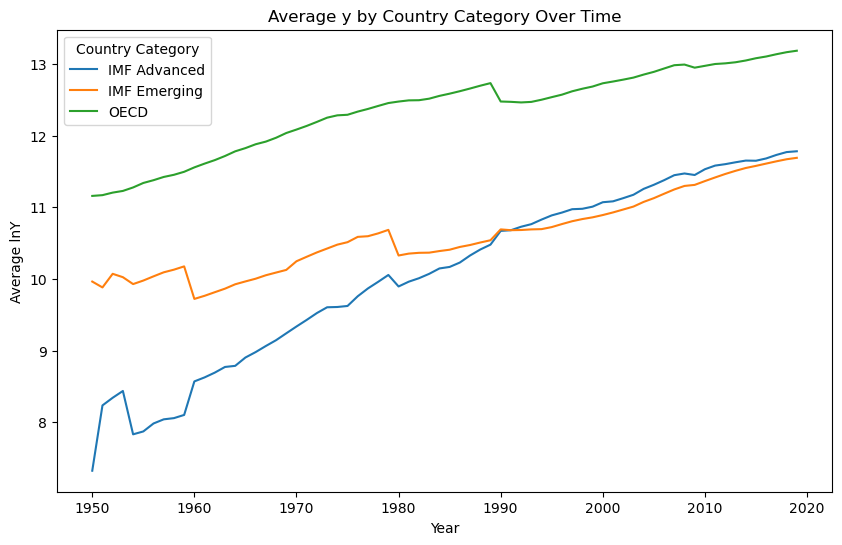

In [40]:
world_data['country_category'] = world_data['countrycode'].apply(categorize_country)

# Calculate the mean ratio for each year
avg_y = world_data.groupby(['year', 'country_category'])['lnY'].mean().unstack()

# Plotting
avg_y.plot(figsize=(10, 6))

# Adding labels and title
plt.title('Average y by Country Category Over Time')
plt.xlabel('Year')
plt.ylabel('Average lnY')

# Adding legend
plt.legend(title='Country Category')

# Show plot
plt.show()

In [41]:
nan_count_per_column = merged_df.isna().sum()
print("Number of NaN values in each column:")
print(nan_count_per_column)

Number of NaN values in each column:
country             0
year                0
FD                  0
FID                 0
FMD                 0
countrycode         0
y                   0
k                   0
emp                 0
hc                  0
labsh               0
cap_out             0
HC                  0
capsh               0
lnY                 0
ln_capsh            0
ln_labsh            0
ln_cap_out          0
ln_cap_out_neg      0
country_category    0
dtype: int64


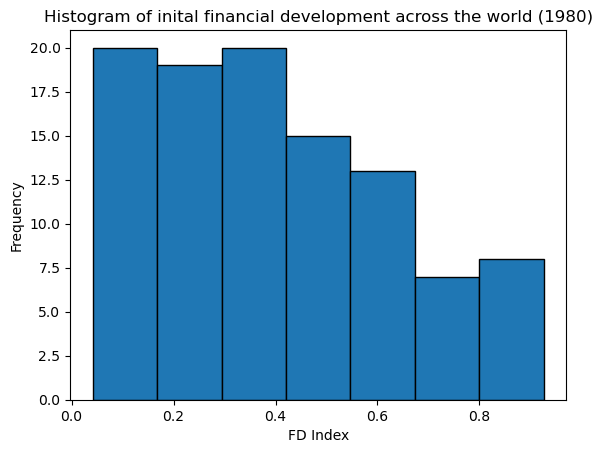

In [42]:
initial_ratios = merged_df.groupby('country')['FD'].first().reset_index()
plt.hist(initial_ratios['FD'], bins=7, edgecolor='black')
plt.title('Histogram of inital financial development across the world (1980)')
plt.xlabel('FD Index')
plt.ylabel('Frequency')
plt.show()

In [43]:
# Define categories based on the initial ratio
bins = np.linspace(0, 1, num=4)
labels = ['Lav FD lande', 'Mellem FD lande', 'Høj FD lande']

# Create a new column for the categories
initial_ratios['FD_Category'] = pd.cut(initial_ratios['FD'], bins=bins, labels=labels, right=False)

# Merge the categories back into the main DataFrame
merged_df = pd.merge(merged_df, initial_ratios[['country', 'FD_Category']], on='country', how='left')
merged_df

,country,year,FD,FID,FMD,countrycode,y,k,emp,hc,...,cap_out,HC,capsh,lnY,ln_capsh,ln_labsh,ln_cap_out,ln_cap_out_neg,country_category,FD_Category
0,Angola,2019,0.096969,0.045453,0.100247,AGO,222151.062500,1.300951e+06,16.644962,1.481984,...,5.856155,24.667574,0.668858,12.311113,-0.402184,-1.105207,1.767493,-1.767493,IMF Emerging,Lav FD lande
1,Angola,2018,0.144027,0.043575,0.066922,AGO,225540.046875,1.292108e+06,16.078331,1.474635,...,5.728951,23.709661,0.668858,12.326253,-0.402184,-1.105207,1.745532,-1.745532,IMF Emerging,Lav FD lande
2,Angola,2017,0.148656,0.049994,0.067229,AGO,230151.343750,1.281953e+06,15.544552,1.467321,...,5.570045,22.808849,0.653629,12.346493,-0.425215,-1.060246,1.717403,-1.717403,IMF Emerging,Lav FD lande
3,Angola,2016,0.154190,0.056435,0.094943,AGO,230491.171875,1.267231e+06,15.028339,1.460044,...,5.497960,21.942038,0.656975,12.347968,-0.420109,-1.069952,1.704377,-1.704377,IMF Emerging,Lav FD lande
4,Angola,2015,0.147570,0.070821,0.075656,AGO,236594.859375,1.233630e+06,14.529098,1.452803,...,5.214103,21.107916,0.650872,12.374104,-0.429442,-1.052318,1.651367,-1.651367,IMF Emerging,Lav FD lande
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3955,Zambia,1984,0.149192,0.040375,0.040194,ZMB,14902.924805,1.874219e+05,1.943763,1.687450,...,12.576181,3.280004,0.554279,9.609313,-0.590087,-0.808062,2.531805,-2.531805,IMF Emerging,Lav FD lande
3956,Zambia,1983,0.156670,0.045299,0.045096,ZMB,14990.561523,1.915574e+05,1.893051,1.656680,...,12.778531,3.136179,0.554279,9.615176,-0.590087,-0.808062,2.547766,-2.547766,IMF Emerging,Lav FD lande
3957,Zambia,1982,0.193317,0.064173,0.063886,ZMB,14561.939453,1.953781e+05,1.861201,1.626470,...,13.417039,3.027187,0.554279,9.586166,-0.590087,-0.808062,2.596525,-2.596525,IMF Emerging,Lav FD lande
3958,Zambia,1981,0.196940,0.067229,0.066928,ZMB,14209.801758,1.983052e+05,1.814478,1.596811,...,13.955520,2.897379,0.554279,9.561687,-0.590087,-0.808062,2.635875,-2.635875,IMF Emerging,Lav FD lande


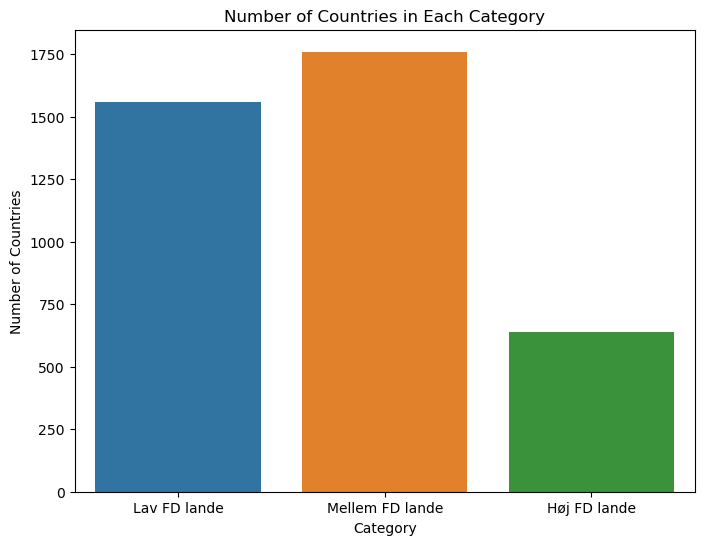

In [47]:
# Assuming 'FD_Category' is the column containing the categories
category_counts = merged_df['FD_Category'].value_counts()

# Plotting the number of countries in each category
plt.figure(figsize=(8, 6))
sns.barplot(x=category_counts.index, y=category_counts.values)
plt.title('Number of Countries in Each Category')
plt.xlabel('Category')
plt.ylabel('Number of Countries')
plt.show()